In [32]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import MinMaxScaler

In [33]:
#1. Prepare Data for Analysis

df = pd.read_csv('D:/Sales.csv')

In [34]:
print(df.head())     # shows first 5 rows
print('-'*60)
print(df.shape)      # shows (rows, columns)

        Date        Time State     Group  Unit  Sales
0  01-Oct-20     Morning    WA      Kids     8  20000
1  01-Oct-20     Morning    WA       Men     8  20000
2  01-Oct-20     Morning    WA     Women     4  10000
3  01-Oct-20     Morning    WA   Seniors    15  37500
4  01-Oct-20   Afternoon    WA      Kids     3   7500
------------------------------------------------------------
(7560, 6)


In [35]:
df.isnull().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [36]:
df.isnull().values.any()

np.False_

In [37]:
df.notna().values.any()

np.True_

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [39]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_22416\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [40]:
df['Date'].head()

0   2020-10-01
1   2020-10-01
2   2020-10-01
3   2020-10-01
4   2020-10-01
Name: Date, dtype: datetime64[ns]

In [41]:
df['Date'] = pd.to_datetime(df['Date'], format="%Y-%m-%d")

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    7560 non-null   datetime64[ns]
 1   Time    7560 non-null   object        
 2   State   7560 non-null   object        
 3   Group   7560 non-null   object        
 4   Unit    7560 non-null   int64         
 5   Sales   7560 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 354.5+ KB


In [43]:
df[['Unit', 'Sales']].describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [44]:
#2. Normalize Data for Analysis
df_dataonly = df[['Unit', 'Sales']]

In [45]:
df_dataonly.head()

,Unit,Sales
0,8,20000
1,8,20000
2,4,10000
3,15,37500
4,3,7500


In [46]:
from sklearn.preprocessing import MinMaxScaler

In [47]:
scaler = MinMaxScaler()

In [48]:
normalize_data = scaler.fit_transform(df_dataonly)

In [49]:
normalize_data.shape

(7560, 2)

In [50]:
normalize_data.min(axis = 0), normalize_data.max(axis = 0)

(array([0., 0.]), array([1., 1.]))

In [51]:
unit_min = normalize_data[:, 0].min()
unit_max = normalize_data[:, 0].max()

sales_min = normalize_data[:, 1].min()
sales_max = normalize_data[:, 1].max()

print("Unit:", unit_min, unit_max)
print("Sales:", sales_min, sales_max)


Unit: 0.0 0.9999999999999999
Sales: 0.0 1.0


In [52]:
#3. Visualize Overall Trends

df_daily = df.groupby('Date')[['Unit', 'Sales']].sum().reset_index()

In [53]:
df_daily.head()

,Date,Unit,Sales
0,2020-10-01,1488,3720000
1,2020-10-02,1486,3715000
2,2020-10-03,1556,3890000
3,2020-10-04,1488,3720000
4,2020-10-05,1545,3862500


In [54]:
df_daily.head()

,Date,Unit,Sales
0,2020-10-01,1488,3720000
1,2020-10-02,1486,3715000
2,2020-10-03,1556,3890000
3,2020-10-04,1488,3720000
4,2020-10-05,1545,3862500


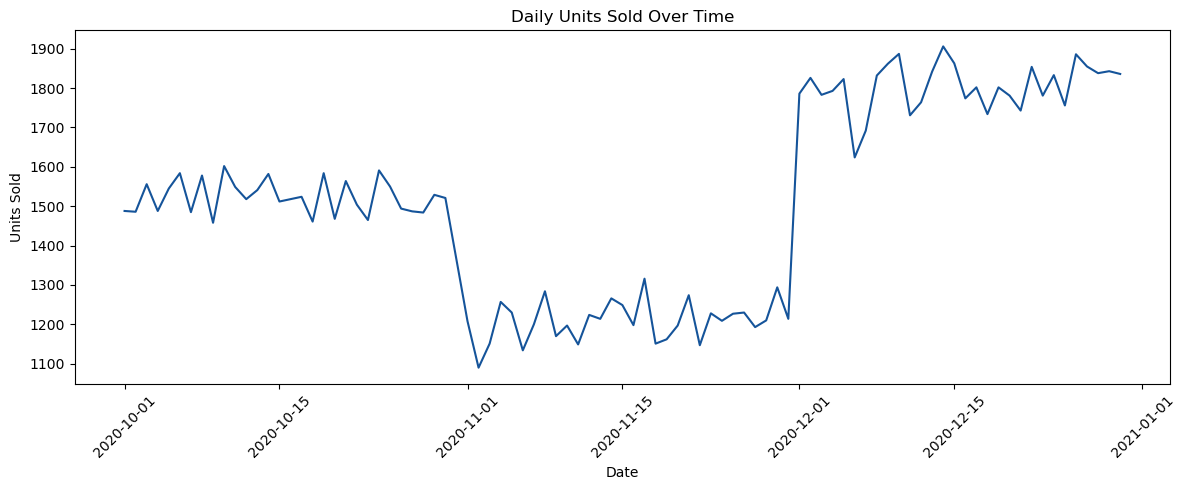

In [55]:
plt.figure(figsize=(12,5))
plt.plot(df_daily['Date'], df_daily['Unit'], color = '#15549A')
plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


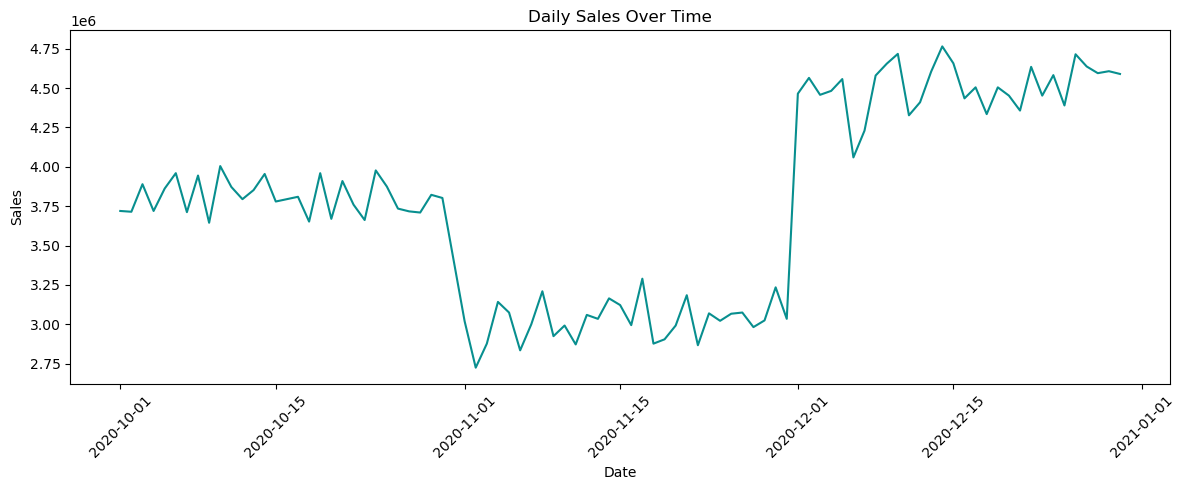

In [58]:
plt.figure(figsize=(12,5))
plt.plot(df_daily['Date'], df_daily['Sales'], color = '#088F8F')
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [59]:
#4. Analyze Monthly Data
df['Date'].min(), df['Date'].max()

(Timestamp('2020-10-01 00:00:00'), Timestamp('2020-12-30 00:00:00'))

In [60]:
df['Date']

0      2020-10-01
1      2020-10-01
2      2020-10-01
3      2020-10-01
4      2020-10-01
          ...    
7555   2020-12-30
7556   2020-12-30
7557   2020-12-30
7558   2020-12-30
7559   2020-12-30
Name: Date, Length: 7560, dtype: datetime64[ns]

In [81]:
#Setting Date as index

In [86]:
df.index

DatetimeIndex(['2020-10-01', '2020-10-01', '2020-10-01', '2020-10-01',
               '2020-10-01', '2020-10-01', '2020-10-01', '2020-10-01',
               '2020-10-01', '2020-10-01',
               ...
               '2020-12-30', '2020-12-30', '2020-12-30', '2020-12-30',
               '2020-12-30', '2020-12-30', '2020-12-30', '2020-12-30',
               '2020-12-30', '2020-12-30'],
              dtype='datetime64[ns]', name='Date', length=7560, freq=None)

In [87]:
oct_data = df.loc['2020-10-01' : '2020-10-31']

In [88]:
nov_data = df.loc['2020-11-01' : '2020-11-30']

In [89]:
dec_data = df.loc['2020-12-01' : '2020-12-31']

In [91]:
oct_data.shape

(2520, 5)

In [92]:
nov_data.shape

(2520, 5)

In [93]:
dec_data.shape

(2520, 5)

In [96]:
oct_total = oct_data[['Unit', 'Sales']].sum()
nov_total = nov_data[['Unit', 'Sales']].sum()
dec_total = dec_data[['Unit', 'Sales']].sum()

oct_total, nov_total, dec_total


(Unit         45716
 Sales    114290000
 dtype: int64,
 Unit        36273
 Sales    90682500
 dtype: int64,
 Unit         54132
 Sales    135330000
 dtype: int64)

In [97]:
oct_avg = oct_data[['Unit', 'Sales']].mean()
nov_avg = nov_data[['Unit', 'Sales']].mean()
dec_avg = dec_data[['Unit', 'Sales']].mean()

oct_avg, nov_avg, dec_avg


(Unit        18.141270
 Sales    45353.174603
 dtype: float64,
 Unit        14.394048
 Sales    35985.119048
 dtype: float64,
 Unit        21.480952
 Sales    53702.380952
 dtype: float64)

In [98]:
monthly_summary = pd.DataFrame({
    'Month': ['October', 'November', 'December'],
    'Total_Units': [oct_total['Unit'], nov_total['Unit'], dec_total['Unit']],
    'Total_Sales': [oct_total['Sales'], nov_total['Sales'], dec_total['Sales']],
    'Avg_Units': [oct_avg['Unit'], nov_avg['Unit'], dec_avg['Unit']],
    'Avg_Sales': [oct_avg['Sales'], nov_avg['Sales'], dec_avg['Sales']]
})

monthly_summary


,Month,Total_Units,Total_Sales,Avg_Units,Avg_Sales
0,October,45716,114290000,18.141270,45353.174603
1,November,36273,90682500,14.394048,35985.119048
2,December,54132,135330000,21.480952,53702.380952


In [104]:
#5. Describe Data
df.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [108]:
oct_data.describe()

,Unit,Sales
count,2520.000000,2520.000000
mean,18.141270,45353.174603
std,11.944521,29861.302213
min,3.000000,7500.000000
25%,9.000000,22500.000000
50%,14.000000,35000.000000
75%,27.000000,67500.000000
max,50.000000,125000.000000


In [109]:
nov_data.describe()

,Unit,Sales
count,2520.000000,2520.000000
mean,14.394048,35985.119048
std,10.946470,27366.175823
min,2.000000,5000.000000
25%,6.000000,15000.000000
50%,10.000000,25000.000000
75%,22.000000,55000.000000
max,45.000000,112500.000000


In [110]:
dec_data.describe()

,Unit,Sales
count,2520.000000,2520.000000
mean,21.480952,53702.380952
std,14.554181,36385.451298
min,5.000000,12500.000000
25%,10.000000,25000.000000
50%,15.000000,37500.000000
75%,31.000000,77500.000000
max,65.000000,162500.000000


In [112]:
# ---------------------------------------------------------------
# Observations from Data Description (Oct–Dec 2020)
# ---------------------------------------------------------------
# • The mean Sales value is closer to the 75% quartile, indicating
#   that Sales are generally on the higher side with fewer low values.
#
# • December shows the highest standard deviation in Sales, meaning
#   sales fluctuated more in December compared to October and November.
#
# • December also recorded the highest total and average Sales,
#   making it the strongest performing month of the quarter.
#
# • All three months contain equal numbers of records (2520 rows each),
#   confirming consistent data collection across the quarter.
# ---------------------------------------------------------------


In [113]:
#6. Analyze Unit Data

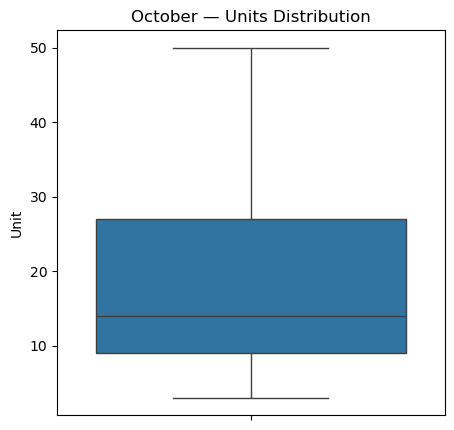

In [114]:
plt.figure(figsize=(5,5))
sns.boxplot(y=oct_data['Unit'])
plt.title("October — Units Distribution")
plt.show()

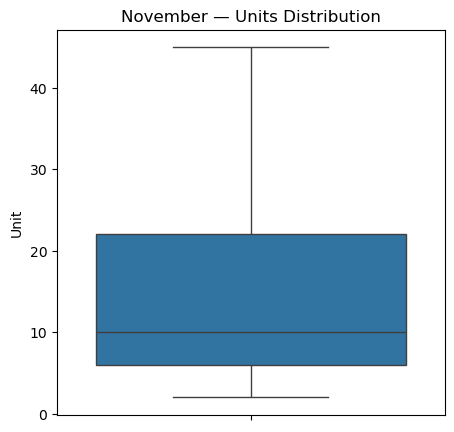

In [116]:
plt.figure(figsize=(5,5))
sns.boxplot(y=nov_data['Unit'])
plt.title("November — Units Distribution")
plt.show()

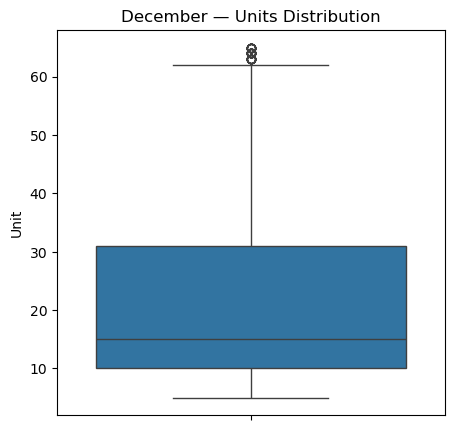

In [118]:
plt.figure(figsize=(5,5))
sns.boxplot(y=dec_data['Unit'])
plt.title("December — Units Distribution")
plt.show()

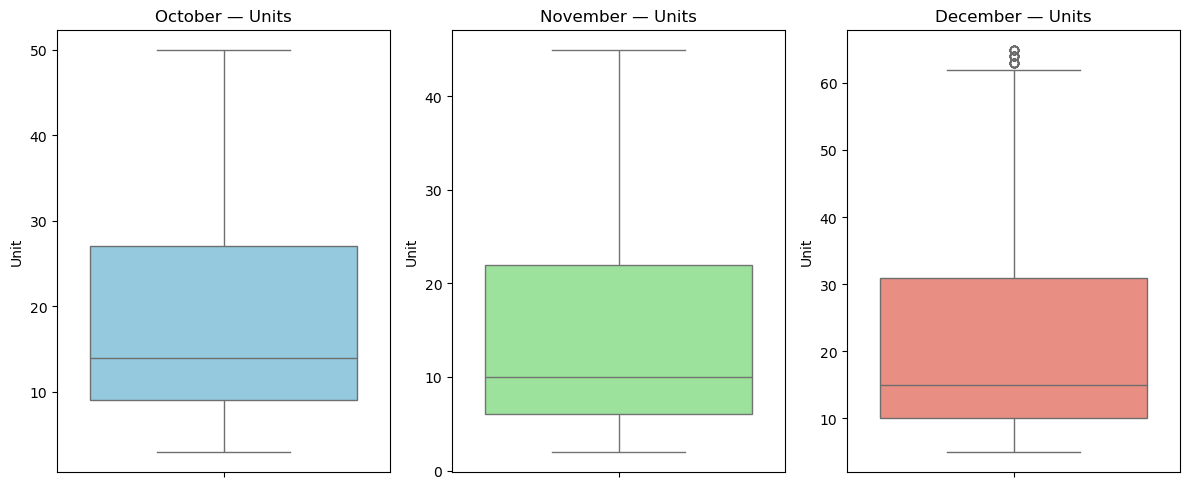

In [134]:
plt.figure(figsize=(12,5))

# 1st subplot — October
plt.subplot(1, 3, 1)
sns.boxplot(y=oct_data['Unit'], color = 'skyblue')
plt.title("October — Units")

# 2nd subplot — November
plt.subplot(1, 3, 2)
sns.boxplot(y=nov_data['Unit'], color = 'lightgreen')
plt.title("November — Units")

# 3rd subplot — December
plt.subplot(1, 3, 3)
sns.boxplot(y=dec_data['Unit'], color = 'salmon')
plt.title("December — Units")

plt.tight_layout()
plt.show()

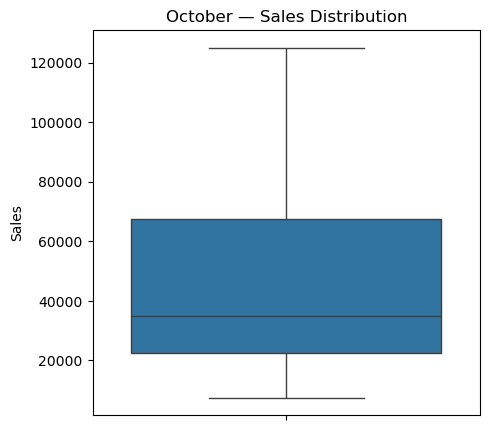

In [120]:
plt.figure(figsize=(5,5))
sns.boxplot(y=oct_data['Sales'])
plt.title("October — Sales Distribution")
plt.show()

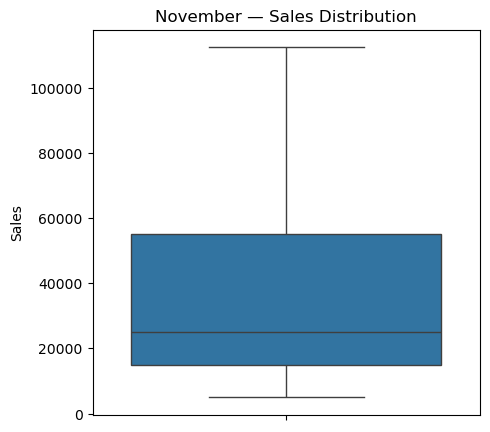

In [123]:
plt.figure(figsize=(5,5))
sns.boxplot(y=nov_data['Sales'])
plt.title("November — Sales Distribution")
plt.show()

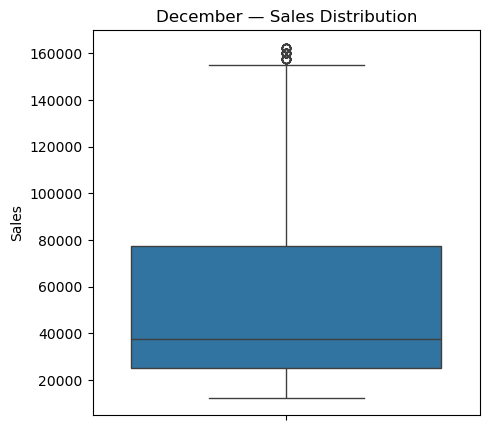

In [124]:
plt.figure(figsize=(5,5))
sns.boxplot(y=dec_data['Sales'])
plt.title("December — Sales Distribution")
plt.show()

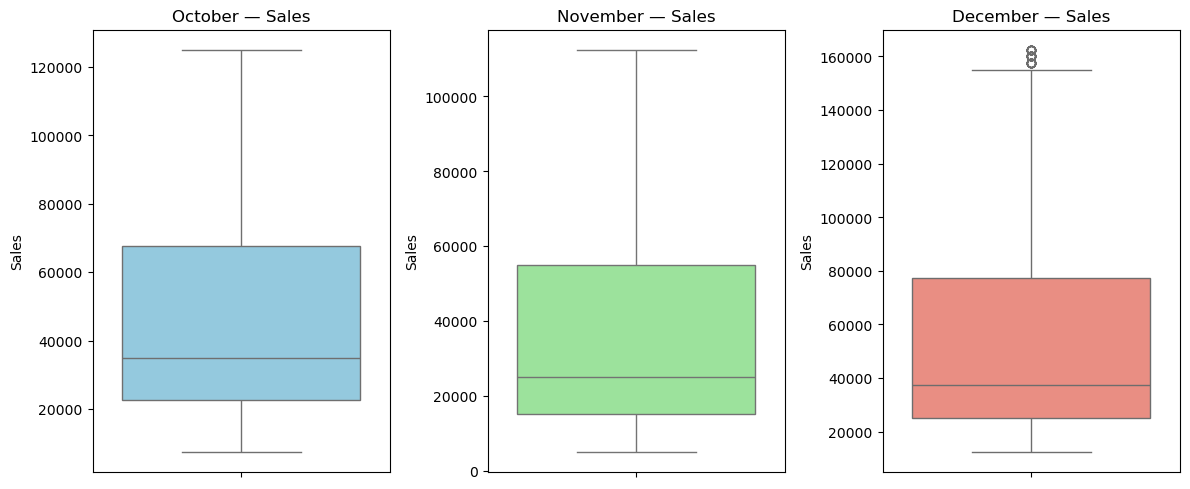

In [136]:
plt.figure(figsize=(12,5))

# 1st subplot — October
plt.subplot(1, 3, 1)
sns.boxplot(y=oct_data['Sales'], color = 'skyblue')
plt.title("October — Sales")

# 2nd subplot — November
plt.subplot(1, 3, 2)
sns.boxplot(y=nov_data['Sales'], color = 'lightgreen')
plt.title("November — Sales")

# 3rd subplot — December
plt.subplot(1, 3, 3)
sns.boxplot(y=dec_data['Sales'], color = 'salmon')
plt.title("December — Sales")

plt.tight_layout()
plt.show()

In [137]:
#7. Explore Monthly Plots and Analysis

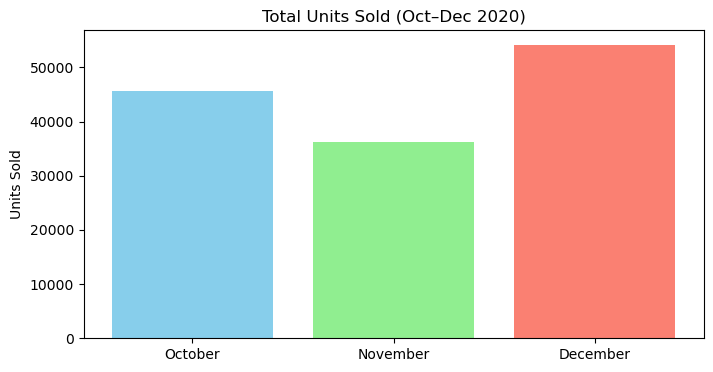

In [138]:
overall_units = [oct_total['Unit'], nov_total['Unit'], dec_total['Unit']]
months = ['October', 'November', 'December']
colors = ['skyblue', 'lightgreen', 'salmon']   # custom colors for bars

plt.figure(figsize=(8,4))
plt.bar(months, overall_units, color = colors)
plt.title("Total Units Sold (Oct–Dec 2020)")
plt.ylabel("Units Sold")
plt.show()


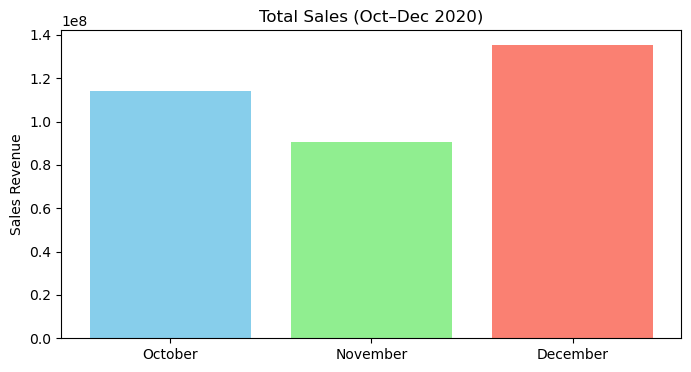

In [139]:
overall_sales = [oct_total['Sales'], nov_total['Sales'], dec_total['Sales']]
months = ['October', 'November', 'December']
colors = ['skyblue', 'lightgreen', 'salmon']   # custom colors for bars
plt.figure(figsize=(8,4))
plt.bar(months, overall_sales, color = colors)
plt.title("Total Sales (Oct–Dec 2020)")
plt.ylabel("Sales Revenue")
plt.show()

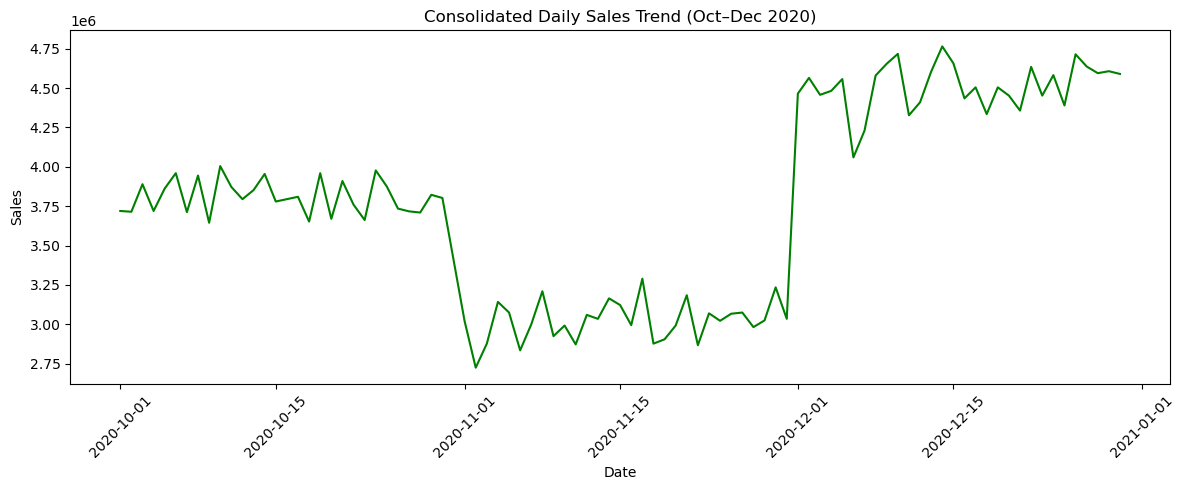

In [142]:
plt.figure(figsize=(12,5))
plt.plot(df_daily['Date'], df_daily['Sales'], color = 'green')
plt.title("Consolidated Daily Sales Trend (Oct–Dec 2020)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [143]:
# ---------------------------------------------------------------
#8. Comprehensive Snapshot
# ---------------------------------------------------------------
# • Dataset covers 3 months (Oct, Nov, Dec) with 2520 rows per month.
# • No missing values and Date column properly converted to datetime.
# • December is the highest-performing month in both Units and Sales.
# • November has the lowest Units and Sales.
# • Mean Sales is closer to the 75% quartile, indicating higher-value
#   distribution with fewer low-sales days.
# • December shows the highest standard deviation and contains outliers,
#   indicating increased variability due to holiday shopping.
# • Monthly boxplots show stable distributions for Oct and Nov, but
#   December displays strong peaks.
# • Consolidated daily sales plot shows a clear rising trend starting
#   early December.
# ---------------------------------------------------------------

In [145]:
#9. Analyze Statewise Sales in the United States

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
state_sales

State
KY     105565000
NY      74970000
FL      58857500
CA      33417500
TX      22760000
AZ      22580000
 WA     22152500
Name: Sales, dtype: int64

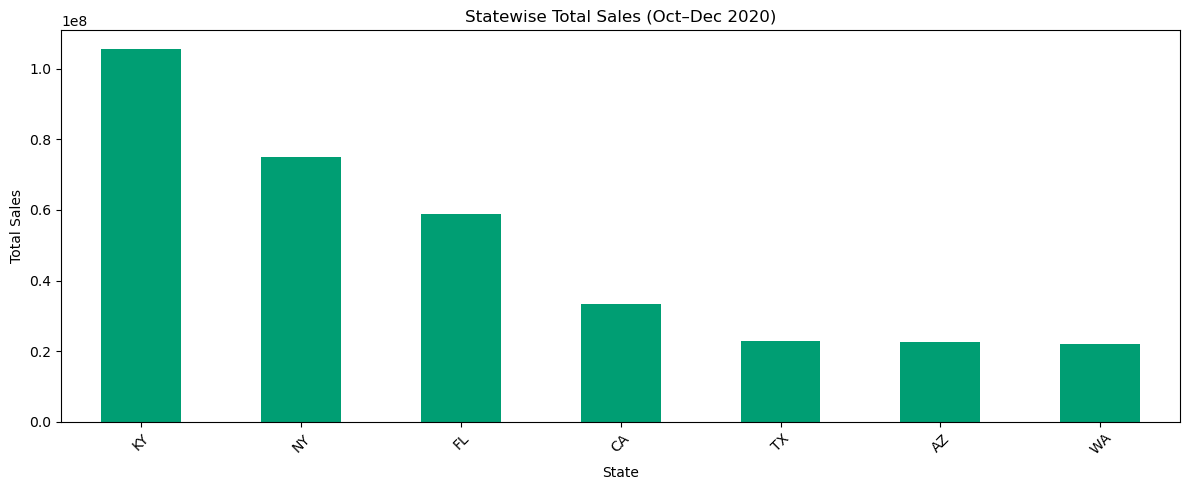

In [147]:
plt.figure(figsize=(12,5))
state_sales.plot(kind='bar', color = '#009E73')
plt.title("Statewise Total Sales (Oct–Dec 2020)")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [148]:
state_summary = df.groupby('State')[['Unit', 'Sales']].sum().sort_values('Sales', ascending=False)
state_summary

,Unit,Sales
State,,
KY,42226,105565000
NY,29988,74970000
FL,23543,58857500
CA,13367,33417500
TX,9104,22760000
AZ,9032,22580000
WA,8861,22152500


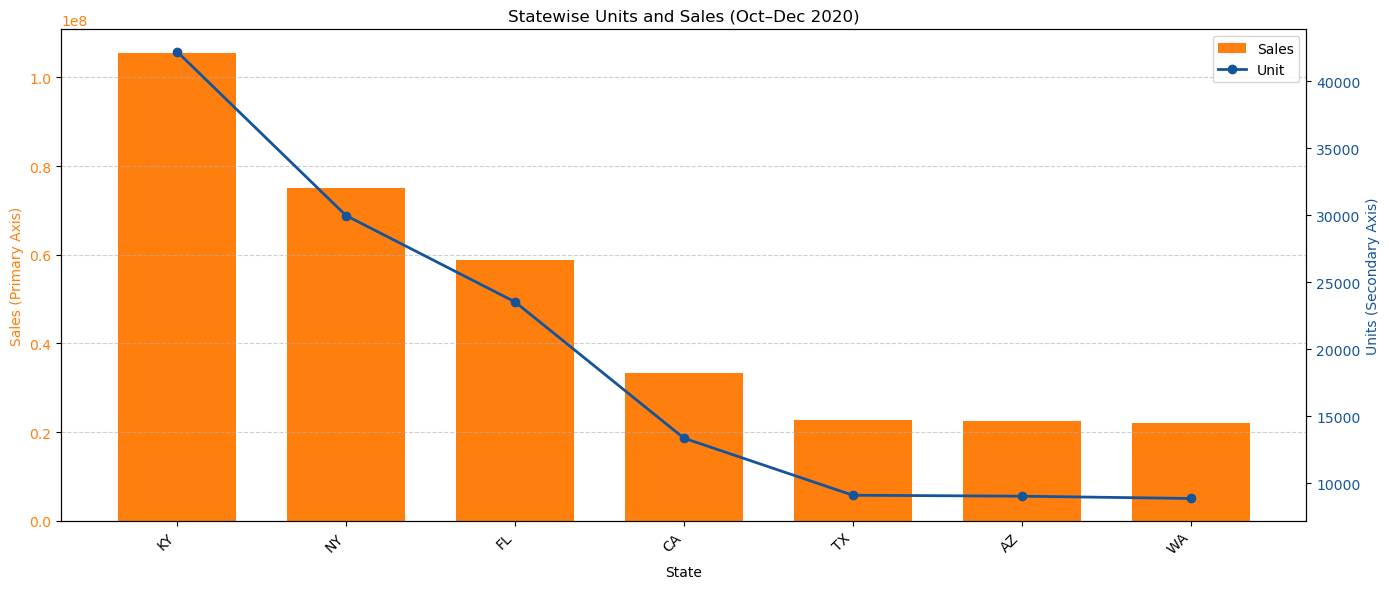

In [172]:
# Create the figure and primary axes (for Sales)
fig, ax1 = plt.subplots(figsize=(14, 6))

ind = np.arange(len(state_summary.index)) # The x locations for the groups

# --- Primary Axis (Sales) - BAR CHART (Left Y-Axis) ---
# Bars are now centered (no offset)
ax1.bar(ind, state_summary['Sales'], width=0.7, label='Sales', color='tab:orange')
ax1.set_xlabel("State")
ax1.set_ylabel("Sales (Primary Axis)", color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# --- Secondary Axis (Unit) - LINE CHART (Right Y-Axis) ---
ax2 = ax1.twinx() # The dual-axis setup remains
# Changed to a line plot, marker added for visibility
ax2.plot(ind, state_summary['Unit'], marker='o', linestyle='-', label='Unit', color='#15549A', linewidth=2)
ax2.set_ylabel("Units (Secondary Axis)", color='#15549A')
ax2.tick_params(axis='y', labelcolor='#15549A')

# --- Final Touches ---
plt.title("Statewise Units and Sales (Oct–Dec 2020)")
# Set x-ticks to the state names
ax1.set_xticks(ind)
ax1.set_xticklabels(state_summary.index, rotation=45, ha="right")

# Combine and show legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right')

plt.tight_layout()
# plt.show()

In [163]:
#10.Conduct Groupwise Analysis
group_summary = df.groupby('Group')[['Unit', 'Sales']].sum().sort_values('Sales', ascending=False)
group_summary

,Unit,Sales
Group,,
Men,34300,85750000
Women,34177,85442500
Kids,34029,85072500
Seniors,33615,84037500


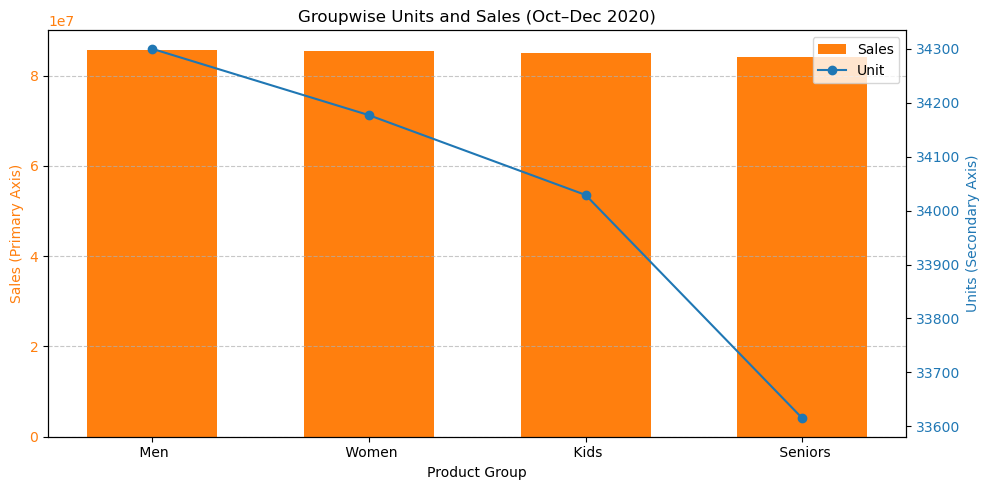

In [174]:
# Create the figure and primary axes (for Sales)
fig, ax1 = plt.subplots(figsize=(10, 5))

# X positions (for plotting)
groups = group_summary.index
ind = np.arange(len(groups))

# --- Primary Axis: Sales (Bar Chart) - LEFT Y-AXIS ---
# Use bars for sales magnitude
ax1.bar(ind, group_summary['Sales'], width=0.6, label='Sales', color='tab:orange')
ax1.set_ylabel("Sales (Primary Axis)", color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')

# --- Secondary Axis: Units (Line Chart) - RIGHT Y-AXIS ---
ax2 = ax1.twinx()
# Use a line plot for units volume/trend
ax2.plot(ind, group_summary['Unit'], marker='o', linestyle='-', label='Unit', color='tab:blue')
ax2.set_ylabel("Units (Secondary Axis)", color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# --- Final Touches ---
plt.title("Groupwise Units and Sales (Oct–Dec 2020)")
ax1.set_xlabel("Product Group")

# Set X labels
ax1.set_xticks(ind)
ax1.set_xticklabels(groups)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [176]:
#11.Explore Timewise Analysis
df['Time'].unique()

array([' Morning', ' Afternoon', ' Evening'], dtype=object)

In [178]:
time_summary = df.groupby('Time')[['Unit', 'Sales']].sum()
time_summary

,Unit,Sales
Time,,
Afternoon,45603,114007500
Evening,44835,112087500
Morning,45683,114207500


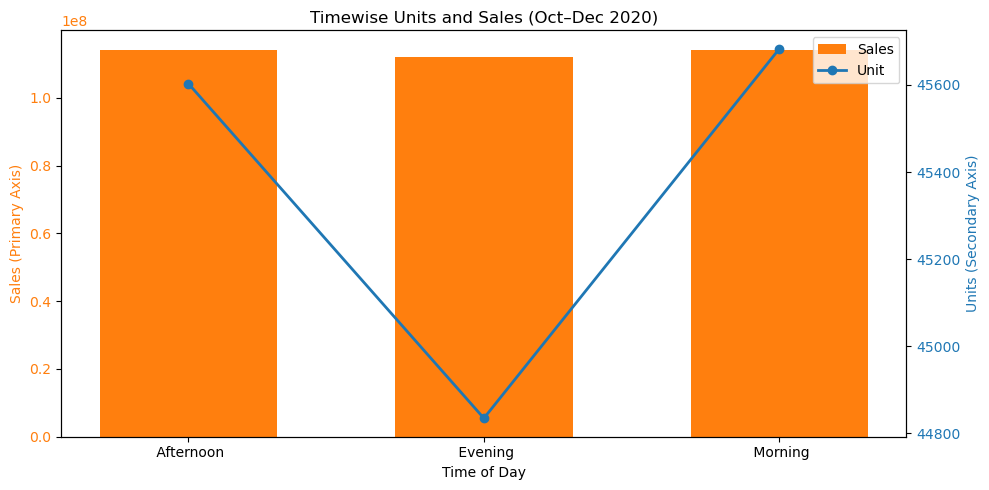

In [179]:
# Create the figure
fig, ax1 = plt.subplots(figsize=(10, 5))

# X positions
times = time_summary.index
ind = np.arange(len(times))

# --- Primary Axis: Sales (Bar Chart) ---
ax1.bar(ind, time_summary['Sales'], width=0.6, label='Sales', color='tab:orange')
ax1.set_ylabel("Sales (Primary Axis)", color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')

# --- Secondary Axis: Units (Line Chart) ---
ax2 = ax1.twinx()
ax2.plot(ind, time_summary['Unit'], marker='o', linewidth=2, label='Unit', color='tab:blue')
ax2.set_ylabel("Units (Secondary Axis)", color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Title and X labels
plt.title("Timewise Units and Sales (Oct–Dec 2020)")
ax1.set_xlabel("Time of Day")
ax1.set_xticks(ind)
ax1.set_xticklabels(times)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()
